## 1. Import Libraries

In [30]:
import pandas as pd
import numpy as np

print("Data Science Internship - Task 1")
print("Pandas version:", pd.__version__)

Data Science Internship - Task 1
Pandas version: 2.2.3


## 2. Load Dataset

In [31]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [32]:
print(df.shape)
print(df.columns)
print(df.info())

(891, 12)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [33]:
print(df["Age"].median())

28.0


In [34]:
df["Age"] = df["Age"].fillna(df["Age"].median())

print(df["Age"].isnull().sum())

0


In [35]:
df = df.drop("Cabin", axis=1)

print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


In [36]:
print(df["Embarked"].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [37]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print(df["Embarked"].isnull().sum())

0


In [38]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [39]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [40]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [41]:
print(df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [42]:
print(df.groupby("Sex")["Survived"].mean())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [43]:
print(df.groupby("Pclass")["Survived"].mean())


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [44]:
print("Average age:", df["Age"].mean())
print("Youngest:", df["Age"].min())
print("Oldest:", df["Age"].max())

Average age: 29.36158249158249
Youngest: 0.42
Oldest: 80.0


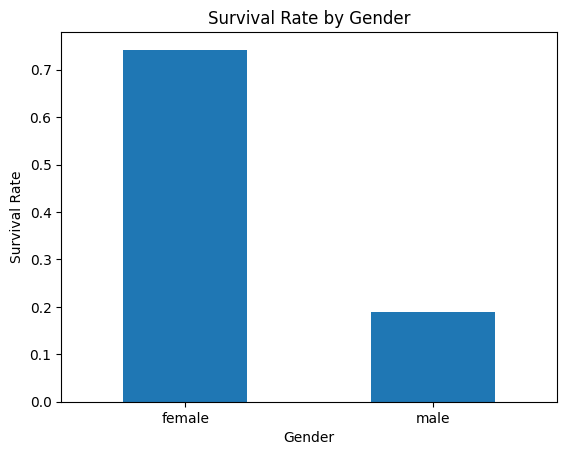

In [45]:
import matplotlib.pyplot as plt

survival_by_sex = df.groupby("Sex")["Survived"].mean()

survival_by_sex.plot(kind="bar")

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()

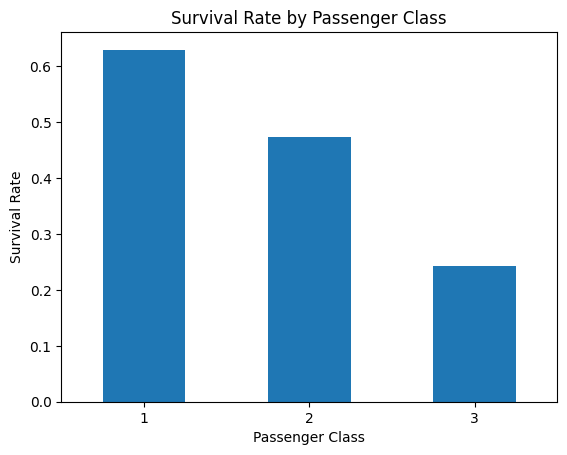

In [46]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()

survival_by_class.plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()

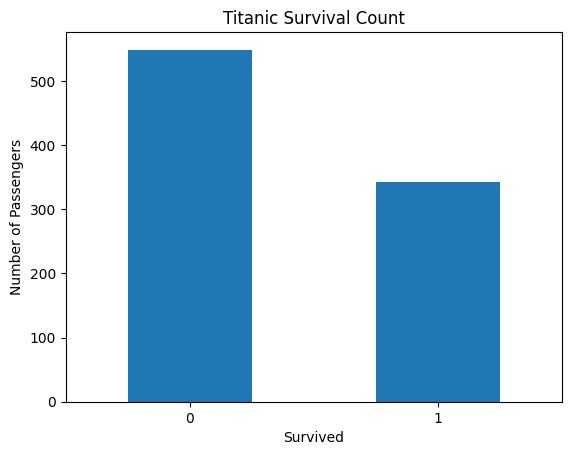

In [47]:
survival_counts = df["Survived"].value_counts()

survival_counts.plot(kind="bar")

plt.title("Titanic Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.show()

In [48]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:")
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Rows: 891
Columns: 11
Missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
Duplicate rows: 0


# Titanic Dataset — Data Cleaning & Analysis

**Data Science Internship — Synent Technologies**

This notebook performs data cleaning, exploratory data analysis, and visualization on the Titanic dataset using Python, Pandas, NumPy, and Matplotlib.


In [49]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object


In [50]:
df["Survived"] = df["Survived"].astype("category")
df["Pclass"] = df["Pclass"].astype("category")

print(df.dtypes)

PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked         object
dtype: object


In [51]:
df = df.rename(columns={
    "PassengerId": "Passenger_ID",
    "Pclass": "Passenger_Class",
    "SibSp": "Siblings_Spouses",
    "Parch": "Parents_Children"
})

print(df.columns)

Index(['Passenger_ID', 'Survived', 'Passenger_Class', 'Name', 'Sex', 'Age',
       'Siblings_Spouses', 'Parents_Children', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


In [52]:
print("Final shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nFinal columns:")
print(df.columns.tolist())

Final shape: (891, 11)

Missing values:
Passenger_ID        0
Survived            0
Passenger_Class     0
Name                0
Sex                 0
Age                 0
Siblings_Spouses    0
Parents_Children    0
Ticket              0
Fare                0
Embarked            0
dtype: int64

Duplicate rows: 0

Final columns:
['Passenger_ID', 'Survived', 'Passenger_Class', 'Name', 'Sex', 'Age', 'Siblings_Spouses', 'Parents_Children', 'Ticket', 'Fare', 'Embarked']


In [53]:
df.to_csv("titanic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [54]:
from google.colab import files

files.download("titanic_cleaned.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Key Findings

- The dataset originally contained 891 passengers and 12 columns.
- Missing values were identified in Age, Cabin, and Embarked.
- Missing Age values were filled using the median age of 28.0.
- The Cabin column was removed because most of its values were missing.
- Missing Embarked values were filled using the most frequent value, S.
- Duplicate rows were checked and none were found.
- Survived and Pclass were converted to categorical data types.
- Selected column names were renamed for clarity.
- Female passengers had a higher survival rate than male passengers.
- First-class passengers had a higher survival rate than second- and third-class passengers.

## 10. Conclusion

The Titanic dataset was successfully cleaned and prepared for analysis using Python, Pandas, NumPy, and Matplotlib. Missing values and duplicates were handled, data types were improved, and column names were made clearer. Exploratory analysis showed differences in survival rates based on gender and passenger class.